# **Email Spam Detection using Bidirectional LSTM (BiLSTM) Deep Learning Model**

In [1]:
!pip install tensorflow

# IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# LOAD DATASET

In [4]:
df = pd.read_csv("/content/spam.csv", encoding="latin-1")

df = df[['v1','v2']]
df.columns = ['label','message']

print(df.shape)
df.head()

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#PREPROCESSING (CLEAN DATA)

In [5]:
df['label'] = df['label'].map({'ham':0, 'spam':1})
df['label'] = df['label'].astype(int)

print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


# (VISUALIZATION SECTION)

# Class Distribution

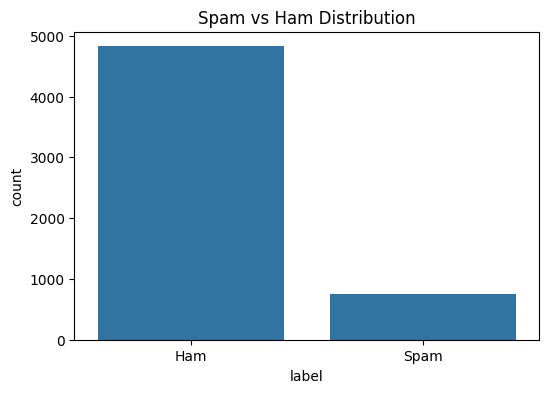

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='label')
plt.xticks([0,1], ['Ham','Spam'])
plt.title("Spam vs Ham Distribution")

plt.show()

# Pie Chart

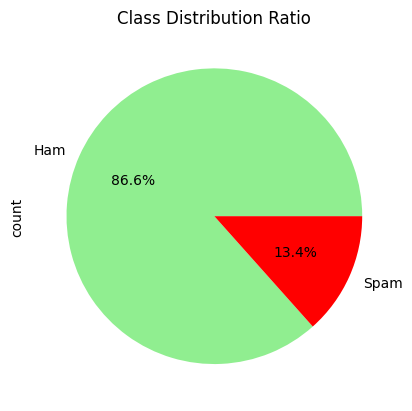

In [7]:
df['label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Ham','Spam'],
    colors=['lightgreen','red']
)

plt.title("Class Distribution Ratio")
plt.show()

# Message Length Distribution

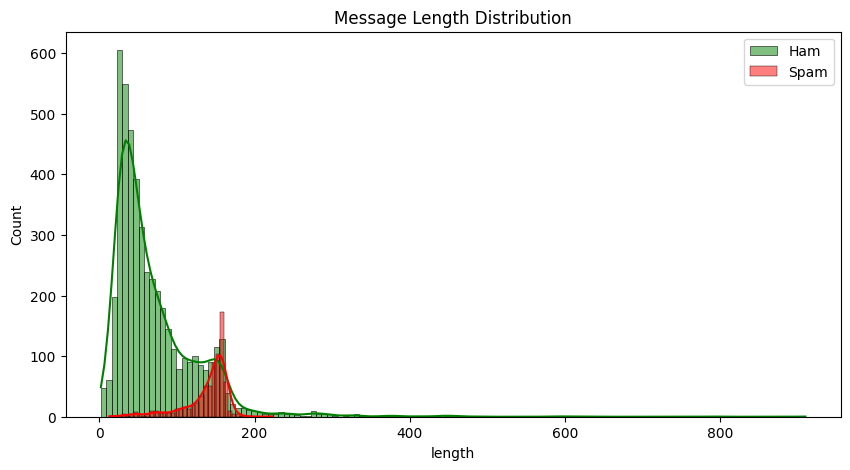

In [8]:
df['length'] = df['message'].apply(len)

plt.figure(figsize=(10,5))

sns.histplot(df[df['label']==0]['length'], color='green', label='Ham', kde=True)
sns.histplot(df[df['label']==1]['length'], color='red', label='Spam', kde=True)

plt.legend()
plt.title("Message Length Distribution")
plt.show()

# WordCloud (SPAM IMAGE)

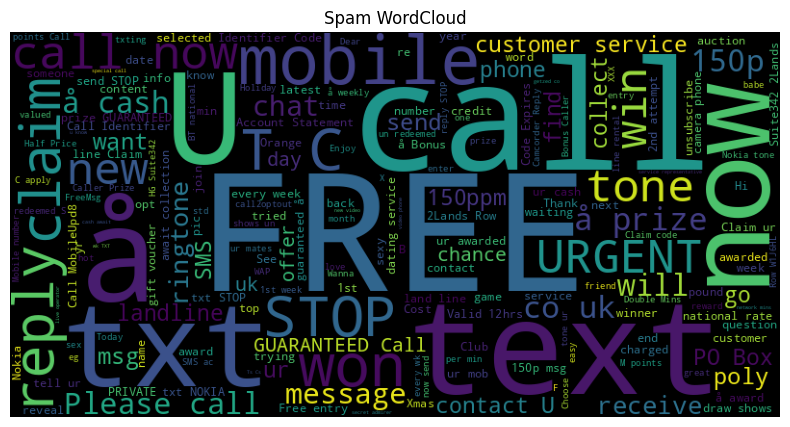

In [9]:
spam_text = " ".join(df[df['label']==1]['message'])

wc = WordCloud(width=800, height=400, background_color='black').generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Spam WordCloud")
plt.show()

# WordCloud (HAM IMAGE)

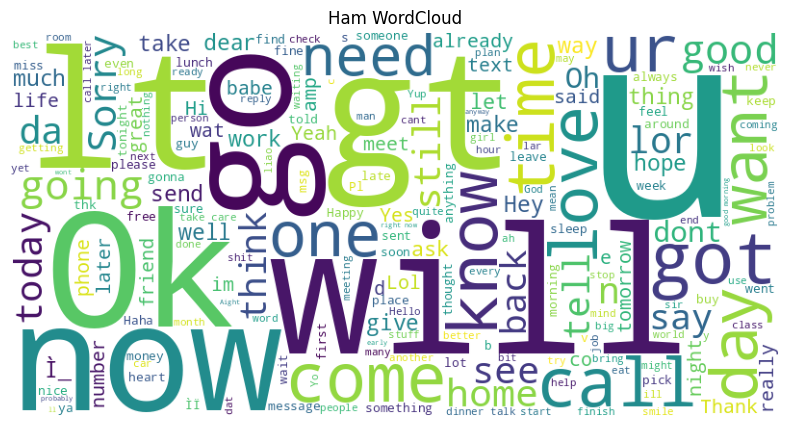

In [10]:
ham_text = " ".join(df[df['label']==0]['message'])

wc = WordCloud(width=800, height=400, background_color='white').generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Ham WordCloud")
plt.show()

# TRAIN TEST SPLIT

In [11]:
X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TOKENIZATION + PADDING

In [12]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 150

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

#MODEL

In [17]:
model = Sequential([

    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=150
    ),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(64)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# COMPILE MODEL

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Build Model

In [19]:
model.build(input_shape=(None,150))

# MODEL SUMMARY

In [20]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 150, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 150, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 150, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,715,841 (6.55 MB)

 Trainable params: 1,715,841 (6.55 MB)

 Non-trainable params: 0 (0.00 B)

# TRAIN MODEL

In [21]:
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9394 - loss: 0.1741 - val_accuracy: 0.9809 - val_loss: 0.0677
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9907 - loss: 0.0382 - val_accuracy: 0.9877 - val_loss: 0.0652
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9989 - loss: 0.0109 - val_accuracy: 0.9809 - val_loss: 0.0781
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9980 - loss: 0.0076 - val_accuracy: 0.9675 - val_loss: 0.2043
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9989 - loss: 0.0077 - val_accuracy: 0.9843 - val_loss: 0.0995
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 1.0000 - loss: 2.4127e-04 - val_accuracy: 0.9854 - val_loss: 0.1101
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 1.0000 - loss: 1.5805e-04 - val_accuracy: 0.9854 - val_loss: 0.1173
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 1.0000 - loss: 8.7147e-

# TRAINING GRAPHS

#Accuracy

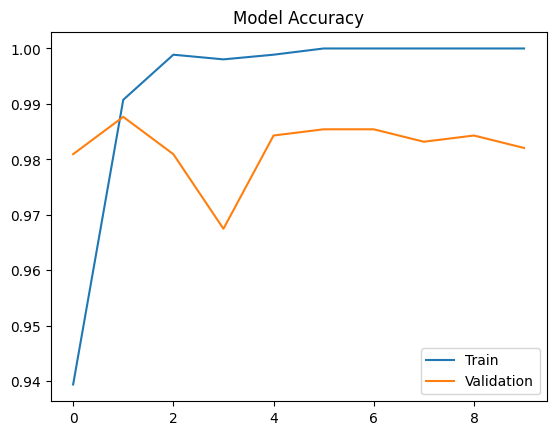

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train','Validation'])
plt.show()

#Loss

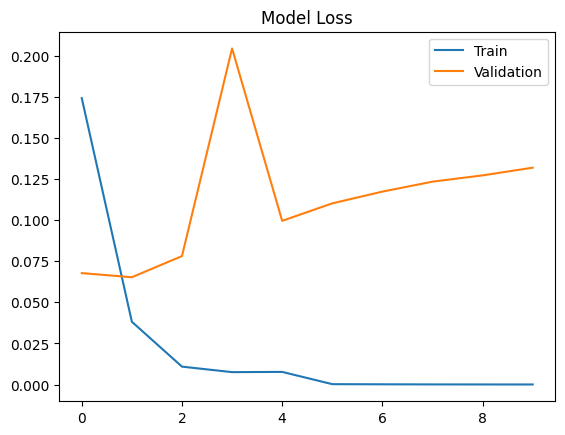

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(['Train','Validation'])
plt.show()

# EVALUATION

In [24]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Accuracy:", acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9839 - loss: 0.1507
Accuracy: 0.9838564991950989


# PREDICTIONS

In [25]:
y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.3).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


# CONFUSION MATRIX

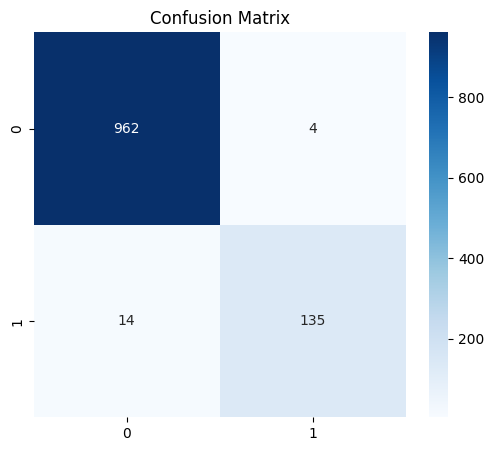

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# CLASSIFICATION REPORT

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.97      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



#REAL TIME PREDICTION

In [30]:
# ================================
#  REAL TIME SPAM PREDICTION
# ================================

def predict_spam(text):

    # Convert text into sequence
    seq = tokenizer.texts_to_sequences([text])

    # Add padding
    pad = pad_sequences(seq, maxlen=max_len, padding='post')

    # Predict
    pred = model.predict(pad, verbose=0)[0][0]

    # Show score
    print("Prediction Score:", pred)

    # Final Result
    if pred > 0.3:
        print(" This message is SPAM")
    else:
        print(" This message is HAM")


# ================================
#  TEST 1
# ================================

predict_spam("Congratulations! You won a free iPhone. Click now!")

# ================================
#  TEST 2
# ================================

predict_spam("Hello Fatima, are we meeting tomorrow?")

Prediction Score: 0.98096
 This message is SPAM
Prediction Score: 3.62379e-06
 This message is HAM


# TEST MODEL

In [31]:
predict_spam("Congratulations you won free iPhone")
predict_spam("Hello how are you?")

Prediction Score: 0.00016844206
 This message is HAM
Prediction Score: 2.723383e-06
 This message is HAM


# SAVE MODEL

In [33]:
model.save("spam_detector_final.keras")